# K-Nearest Neighbour Regression for Blast-Induced Peak Deformation Prediction

> **Notebook structure**  
> 1. [Environment & Reproducibility](#1-environment)  
> 2. [Data Ingestion & Feature Engineering](#2-data)  
> 3. [Model Definitions](#3-models)  
> 4. [Hyper-parameter Search](#4-tuning)  
> 5. [Model Training & Timing](#5-training)  
> 6. [Performance Evaluation](#6-evaluation)  
> 7. [Cross-Validation](#7-cv)  
> 8. [Research Visualisations](#8-viz)  
> 9. [SHAP Interpretability](#9-shap)

---

## 1. Environment & Reproducibility <a id='1-environment'></a>

In [69]:
# ── Standard & Scientific ────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
import time
warnings.filterwarnings('ignore')

from scipy.spatial.distance import cdist
from scipy.optimize import differential_evolution, minimize
from scipy.linalg import pinv

# ── Scikit-Learn ─────────────────────────────────────────────────────────────
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.preprocessing import StandardScaler, LabelEncoder, PowerTransformer
from sklearn.model_selection import cross_val_score, train_test_split, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_squared_error, r2_score,
    mean_absolute_error, explained_variance_score,
    max_error, mean_squared_log_error,
    median_absolute_error, mean_absolute_percentage_error,
    mean_pinball_loss, mean_tweedie_deviance
)

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D
import seaborn as sns
from math import pi

# ── SHAP ─────────────────────────────────────────────────────────────────────
import shap

# ── Global Style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 11,
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 11,
    'legend.fontsize'  : 10,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Data Ingestion & Feature Engineering <a id='2-data'></a>

In [70]:
# ── 2.1  Load & clean ────────────────────────────────────────────────────────
df = pd.read_excel('data-p.xlsx')
processed_data = df.copy()
processed_data.columns = [col.strip() for col in processed_data.columns]

# ── 2.2  Engineered interaction features ────────────────────────────────────
if all(c in processed_data.columns for c in ['dimensions', 'span length of specimen']):
    processed_data['aspect_ratio'] = (
        processed_data['span length of specimen'] / processed_data['dimensions']
    )

if all(c in processed_data.columns for c in ['axial load ratio', 'confinement']):
    processed_data['load_confinement_interaction'] = (
        processed_data['axial load ratio'] / processed_data['confinement']
    )

if all(c in processed_data.columns for c in ['axial load ratio', 'scaled stand off distance']):
    processed_data['loading_interaction'] = (
        processed_data['scaled stand off distance'] * processed_data['axial load ratio']
    )

# ── 2.3  Drop raw columns that were superseded by engineered features ─────────
TARGET_COL = 'peak deformation (mm)'
DROP_COLS  = ['dimensions', 'span length of specimen',
              'grade of concrete(Mpa)', 'yield strength of the steel (Mpa)']
processed_data = processed_data.drop(columns=DROP_COLS)

X = processed_data.drop(columns=[TARGET_COL])
y = processed_data[TARGET_COL]

# Formal feature labels (used throughout for all plots & tables)
FEATURE_LABELS = {
    'scaled stand off distance'   : r'Scaled Standoff Distance $Z$ ($\mathrm{m/kg}^{1/3}$)',
    'axial load ratio'            : r'Axial Load Ratio $n$ (-)',
    'confinement'                 : r'Confinement Factor $\xi$ (-)',
    'loading_interaction'         : r'Loading Interaction (-)',
    'aspect_ratio'                : r'Aspect Ratio (-)',
    'load_confinement_interaction': r'Load-Confinement Interaction (-)',
    'peak deformation (mm)'       : r'Peak Deformation $\delta$ (mm)',
    'Rx2'                         : r'End-support Conditions (-)',
    'shape of the cross section'  : r'Cross-section Shape (-)'
}
FEATURE_NAMES = list(X.columns)   # ordered list used for SHAP

# ── 2.4  Encode categorical feature ──────────────────────────────────────────
le = LabelEncoder()
X['shape of the cross section'] = le.fit_transform(X['shape of the cross section'])

# ── 2.5  Train / test split ───────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# ── 2.6  Outlier removal from training set only (IQR-based) ──────────────────
Q1, Q3 = y_train.quantile(0.25), y_train.quantile(0.75)
IQR    = Q3 - Q1
lb, ub = Q1 - 4.0 * IQR, Q3 + 1.5 * IQR
valid_mask = (y_train >= lb) & (y_train <= ub)
X_train, y_train = X_train[valid_mask].reset_index(drop=True), \
                   y_train[valid_mask].reset_index(drop=True)

# ── 2.7  Yeo-Johnson power transform for skewed features ──────────────────────
SKEWED_FEATURES = ['scaled stand off distance', 'confinement']
pt = PowerTransformer(method='yeo-johnson')
X_train[SKEWED_FEATURES] = pt.fit_transform(X_train[SKEWED_FEATURES])
X_test[SKEWED_FEATURES]  = pt.transform(X_test[SKEWED_FEATURES])

# ── 2.8  Standardisation ──────────────────────────────────────────────────────
scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(
    f"  Training samples (after outlier removal) : {X_train_s.shape[0]}\n"
    f"  Test samples                              : {X_test_s.shape[0]}\n"
    f"  Features                                  : {X_train_s.shape[1]}\n"
    f"  Target range (train)                      : [{y_train.min():.2f}, {y_train.max():.2f}] mm"
)

  Training samples (after outlier removal) : 111
  Test samples                              : 30
  Features                                  : 8
  Target range (train)                      : [0.00, 49.10] mm


## 3. Model Definitions <a id='3-models'></a>

Five KNN variants are implemented as scikit-learn–compatible estimators.

| Model | Key idea |
|---|---|
| **ε-KNN** | Fixed-radius neighbourhood; neighbour count varies per query |
| **Adaptive-K KNN** | Local density estimate adjusts *K* per query |
| **Kernel-KNN** | Smooth kernel weighting (Quartic kernel selected) |
| **LW-KNN (LOWESS)** | Local linear fit weighted by Tricube kernel |
| **Optimised KNN** | GA/PSO/BO joint search over (*K*, metric, weighting) |

In [71]:
# ════════════════════════════════════════════════════════════════════════════
# 3.1  ε-KNN  —  Fixed-radius neighbourhood regressor
# ════════════════════════════════════════════════════════════════════════════
class RadiusKNNRegressor(BaseEstimator, RegressorMixin):
    """
    ε-KNN: all neighbours within a fixed Euclidean radius are used.
    Neighbour count *K* varies per query point.
    Falls back to `min_samples` nearest neighbours when the neighbourhood
    is empty to prevent NaN predictions.
    """

    def __init__(self, radius: float = 1.0, weights: str = 'distance',
                 min_samples: int = 1):
        self.radius      = radius
        self.weights     = weights
        self.min_samples = min_samples

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.X_train_ = X.copy()
        self.y_train_ = y.copy()
        return self

    def predict(self, X):
        check_is_fitted(self)
        X = check_array(X)
        dists = cdist(X, self.X_train_, metric='euclidean')
        preds = np.empty(len(X))

        for i, d in enumerate(dists):
            mask = d <= self.radius
            if mask.sum() < self.min_samples:
                idx   = np.argsort(d)[:self.min_samples]
                d_sel = d[idx]; y_sel = self.y_train_[idx]
            else:
                d_sel = d[mask]; y_sel = self.y_train_[mask]

            if self.weights == 'distance':
                w = 1.0 / np.where(d_sel == 0, 1e-10, d_sel)
                preds[i] = np.dot(w, y_sel) / w.sum()
            else:
                preds[i] = y_sel.mean()

        return preds

In [72]:
# ════════════════════════════════════════════════════════════════════════════
# 3.2  Adaptive-K KNN  —  Density-aware neighbour count
# ════════════════════════════════════════════════════════════════════════════
class AdaptiveKNNRegressor(BaseEstimator, RegressorMixin):
    """
    Local density is estimated via the mean distance to k_pilot nearest
    neighbours.  Dense regions use a smaller K (fine-grained model);
    sparse regions use a larger K (more support points).

        k_eff = clip( round(k_base / density_ratio), k_min, k_max )
    """

    def __init__(self, k_base: int = 10, k_pilot: int = 5,
                 k_min: int = 2, k_max: int = 30, weights: str = 'distance'):
        self.k_base  = k_base;  self.k_pilot = k_pilot
        self.k_min   = k_min;   self.k_max   = k_max
        self.weights = weights

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.X_train_ = X.copy(); self.y_train_ = y.copy()
        D = cdist(X, X, metric='euclidean')
        np.fill_diagonal(D, np.inf)
        self.local_density_train_ = np.sort(D, axis=1)[:, :self.k_pilot].mean(axis=1)
        self.global_mean_dist_    = self.local_density_train_.mean()
        return self

    def predict(self, X):
        check_is_fitted(self)
        X = check_array(X)
        D = cdist(X, self.X_train_, metric='euclidean')
        preds = np.empty(len(X))
        for i, d in enumerate(D):
            local_d      = np.sort(d)[:self.k_pilot].mean()
            density_ratio = local_d / (self.global_mean_dist_ + 1e-10)
            k_eff = int(np.clip(round(self.k_base / density_ratio), self.k_min, self.k_max))
            idx = np.argsort(d)[:k_eff]
            d_k = d[idx]; y_k = self.y_train_[idx]
            if self.weights == 'distance':
                w = 1.0 / np.where(d_k == 0, 1e-10, d_k)
                preds[i] = np.dot(w, y_k) / w.sum()
            else:
                preds[i] = y_k.mean()
        return preds

In [73]:
# ════════════════════════════════════════════════════════════════════════════
# 3.3  Kernel-KNN  —  Smooth kernel weighting
# ════════════════════════════════════════════════════════════════════════════
class KernelKNNRegressor(BaseEstimator, RegressorMixin):
    """
    KNN with kernel-smoothed weights (u = d / bandwidth).

    Supported kernels:
      gaussian     : exp(−0.5 u²)
      epanechnikov : 0.75(1−u²)  for |u|≤1
      triangular   : (1−|u|)     for |u|≤1
      uniform      : 1           for |u|≤1
      quartic      : (15/16)(1−u²)²  for |u|≤1
    """

    KERNELS = ('gaussian', 'epanechnikov', 'triangular', 'uniform', 'quartic')

    def __init__(self, n_neighbors: int = 15, kernel: str = 'gaussian',
                 bandwidth: str = 'auto'):
        self.n_neighbors = n_neighbors
        self.kernel      = kernel
        self.bandwidth   = bandwidth

    def _kernel_weights(self, distances, h):
        u = distances / (h + 1e-12)
        k = self.kernel
        if k == 'gaussian'     : return np.exp(-0.5 * u**2)
        if k == 'epanechnikov' : return np.where(np.abs(u)<=1, 0.75*(1-u**2), 0.0)
        if k == 'triangular'   : return np.where(np.abs(u)<=1, 1-np.abs(u), 0.0)
        if k == 'uniform'      : return np.where(np.abs(u)<=1, 1.0, 0.0)
        if k == 'quartic'      : return np.where(np.abs(u)<=1, (15/16)*(1-u**2)**2, 0.0)
        raise ValueError(f'Unknown kernel: {k}')

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.X_train_ = X.copy(); self.y_train_ = y.copy()
        return self

    def predict(self, X):
        check_is_fitted(self)
        X = check_array(X)
        D = cdist(X, self.X_train_, metric='euclidean')
        preds = np.empty(len(X))
        for i, d in enumerate(D):
            idx = np.argsort(d)[:self.n_neighbors]
            d_k = d[idx]; y_k = self.y_train_[idx]
            h   = d_k.max() if self.bandwidth == 'auto' else float(self.bandwidth)
            w   = self._kernel_weights(d_k, h)
            w_sum = w.sum()
            preds[i] = (np.dot(w, y_k) / w_sum) if w_sum > 0 else y_k.mean()
        return preds

In [74]:
# ════════════════════════════════════════════════════════════════════════════
# 3.4  Locally Weighted KNN (LOWESS)  —  Local linear regression
# ════════════════════════════════════════════════════════════════════════════
class LocallyWeightedKNNRegressor(BaseEstimator, RegressorMixin):
    """
    Fits a local linear model within the K-neighbourhood of each query
    point using Tricube (default) kernel weights.
    """

    def __init__(self, n_neighbors: int = 20, local_model: str = 'linear',
                 kernel: str = 'tricube', reg_alpha: float = 1e-3):
        self.n_neighbors = n_neighbors
        self.local_model = local_model
        self.kernel      = kernel
        self.reg_alpha   = reg_alpha

    def _kernel_weights(self, u):
        if self.kernel == 'tricube':
            return np.where(u < 1, (1 - np.abs(u)**3)**3, 0.0)
        if self.kernel == 'gaussian':
            return np.exp(-0.5 * (u * 3)**2)   # σ ≈ h/3
        if self.kernel == 'epanechnikov':
            return np.where(np.abs(u)<=1, 0.75*(1-u**2), 0.0)
        raise ValueError(f'Unknown kernel: {self.kernel}')

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.X_train_ = X.copy(); self.y_train_ = y.copy()
        return self

    def predict(self, X):
        check_is_fitted(self)
        X = check_array(X)
        D = cdist(X, self.X_train_, metric='euclidean')
        preds = np.empty(len(X))
        for i, (d, x_q) in enumerate(zip(D, X)):
            idx = np.argsort(d)[:self.n_neighbors]
            d_k = d[idx]; y_k = self.y_train_[idx]; X_k = self.X_train_[idx]
            h   = d_k.max() + 1e-12
            w   = self._kernel_weights(d_k / h)

            if self.local_model == 'constant' or X_k.shape[0] <= X_k.shape[1] + 1:
                preds[i] = np.dot(w, y_k) / (w.sum() + 1e-10)
            else:
                W    = np.diag(w)
                A    = np.column_stack([np.ones(len(X_k)), X_k])
                AtW  = A.T @ W
                AtWA = AtW @ A + self.reg_alpha * np.eye(A.shape[1])
                AtWy = AtW @ y_k
                try:
                    beta = np.linalg.solve(AtWA, AtWy)
                except np.linalg.LinAlgError:
                    beta = pinv(AtWA) @ AtWy
                preds[i] = np.r_[1.0, x_q] @ beta
        return preds

In [75]:
# ════════════════════════════════════════════════════════════════════════════
# 3.5  Optimised KNN  —  Meta-heuristic hyper-parameter search
# ════════════════════════════════════════════════════════════════════════════
class OptimisedKNNRegressor(BaseEstimator, RegressorMixin):
    """
    Jointly optimises (K, distance metric, weight scheme) via one of:
      'ga'       — Differential Evolution (scipy)
      'pso'      — Particle Swarm Optimisation (vectorised, no external lib)
      'bayesian' — Random-restart Nelder-Mead surrogate
    """

    _METRICS = ['euclidean', 'manhattan', 'minkowski', 'chebyshev']
    _WEIGHTS = ['uniform', 'distance']
    _K_RANGE = (2, 30)

    def __init__(self, strategy: str = 'ga', cv: int = 3,
                 max_iter: int = 30, n_particles: int = 15,
                 random_state: int = 42):
        self.strategy     = strategy
        self.cv           = cv
        self.max_iter     = max_iter
        self.n_particles  = n_particles
        self.random_state = random_state

    @staticmethod
    def _build_knn(params):
        k   = max(2, int(round(params[0])))
        met = OptimisedKNNRegressor._METRICS[int(round(params[1])) % len(OptimisedKNNRegressor._METRICS)]
        w   = OptimisedKNNRegressor._WEIGHTS[int(round(params[2])) % len(OptimisedKNNRegressor._WEIGHTS)]
        return KNeighborsRegressor(n_neighbors=k, metric=met, weights=w, algorithm='brute')

    def _objective(self, params, X, y):
        scores = cross_val_score(self._build_knn(params), X, y,
                                 cv=self.cv, scoring='neg_root_mean_squared_error')
        return -scores.mean()

    @property
    def _bounds(self):
        return [self._K_RANGE,
                (0, len(self._METRICS) - 1),
                (0, len(self._WEIGHTS) - 1)]

    def _optimise_ga(self, X, y):
        res = differential_evolution(self._objective, self._bounds,
                                     args=(X, y), maxiter=self.max_iter,
                                     popsize=self.n_particles,
                                     seed=self.random_state, tol=1e-4, polish=False)
        return res.x

    def _optimise_pso(self, X, y):
        rng = np.random.default_rng(self.random_state)
        bounds = np.array(self._bounds)
        lo, hi = bounds[:, 0], bounds[:, 1]
        n, d   = self.n_particles, len(bounds)
        pos    = rng.uniform(lo, hi, (n, d))
        vel    = rng.uniform(-(hi-lo), hi-lo, (n, d)) * 0.1
        pbest_pos = pos.copy()
        pbest_val = np.array([self._objective(p, X, y) for p in pos])
        gbest_idx = pbest_val.argmin()
        gbest_pos = pbest_pos[gbest_idx].copy()
        gbest_val = pbest_val[gbest_idx]
        for _ in range(self.max_iter):
            r1, r2 = rng.random((n, d)), rng.random((n, d))
            vel    = 0.7*vel + 1.5*r1*(pbest_pos-pos) + 1.5*r2*(gbest_pos-pos)
            pos    = np.clip(pos + vel, lo, hi)
            vals   = np.array([self._objective(p, X, y) for p in pos])
            better = vals < pbest_val
            pbest_pos[better] = pos[better]; pbest_val[better] = vals[better]
            g = pbest_val.argmin()
            if pbest_val[g] < gbest_val:
                gbest_val = pbest_val[g]; gbest_pos = pbest_pos[g].copy()
        return gbest_pos

    def _optimise_bayesian(self, X, y):
        rng = np.random.default_rng(self.random_state)
        bounds = np.array(self._bounds)
        lo, hi = bounds[:, 0], bounds[:, 1]
        best_val, best_x = np.inf, None
        for _ in range(self.n_particles):
            x0  = rng.uniform(lo, hi)
            res = minimize(self._objective, x0, args=(X, y), method='Nelder-Mead',
                           options={'maxiter': self.max_iter, 'xatol': 0.5, 'fatol': 0.01})
            if res.fun < best_val:
                best_val, best_x = res.fun, res.x
        return best_x

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        dispatch = {'ga': self._optimise_ga, 'pso': self._optimise_pso,
                    'bayesian': self._optimise_bayesian}
        best_params        = dispatch[self.strategy](X, y)
        k   = max(2, int(round(best_params[0])))
        met = self._METRICS[int(round(best_params[1])) % len(self._METRICS)]
        w   = self._WEIGHTS[int(round(best_params[2])) % len(self._WEIGHTS)]
        self.best_k_       = k
        self.best_metric_  = met
        self.best_weights_ = w
        self.best_params_  = best_params
        self.estimator_    = KNeighborsRegressor(n_neighbors=k, metric=met,
                                                  weights=w, algorithm='brute')
        self.estimator_.fit(X, y)
        return self

    def predict(self, X):
        check_is_fitted(self)
        return self.estimator_.predict(check_array(X))

## 4. Hyper-parameter Ranges <a id='4-tuning'></a>

In [76]:
# ════════════════════════════════════════════════════════════════════════════
# 4.1  Hyper-parameter search spaces
# ════════════════════════════════════════════════════════════════════════════
HP_RANGES = pd.DataFrame([
    # ε-KNN
    {'Model': 'ε-KNN',         'Parameter': 'radius',      'Range / Options': '[0.1, 5.0]',                          'Selected': '0.5'},
    {'Model': 'ε-KNN',         'Parameter': 'weights',     'Range / Options': "{'uniform', 'distance'}",             'Selected': 'distance'},
    {'Model': 'ε-KNN',         'Parameter': 'min_samples', 'Range / Options': '[1, 10]',                             'Selected': '1'},
    # Adaptive-K
    {'Model': 'Adaptive-K KNN','Parameter': 'k_base',      'Range / Options': '[5, 30]',                             'Selected': '8'},
    {'Model': 'Adaptive-K KNN','Parameter': 'k_pilot',     'Range / Options': '[2, 10]',                             'Selected': '4'},
    {'Model': 'Adaptive-K KNN','Parameter': 'k_min / k_max','Range / Options':'[2, 5] / [20, 50]',                   'Selected': '2 / 30'},
    # Kernel-KNN
    {'Model': 'Kernel-KNN',    'Parameter': 'n_neighbors', 'Range / Options': '[5, 30]',                             'Selected': '15'},
    {'Model': 'Kernel-KNN',    'Parameter': 'kernel',      'Range / Options': "{'gaussian','epanechnikov','triangular','uniform','quartic'}", 'Selected': 'quartic'},
    # LW-KNN
    {'Model': 'LW-KNN (LOWESS)','Parameter': 'n_neighbors','Range / Options': '[5, 20]',                             'Selected': '5'},
    {'Model': 'LW-KNN (LOWESS)','Parameter': 'kernel',     'Range / Options': "{'tricube','gaussian','epanechnikov'}",'Selected': 'tricube'},
    {'Model': 'LW-KNN (LOWESS)','Parameter': 'reg_alpha',  'Range / Options': '[1e-4, 1e-1]',                        'Selected': '1e-3'},
    # Optimised KNN
    {'Model': 'Opt-KNN (GA/PSO/BO)','Parameter': 'K',      'Range / Options': '[2, 30]',                             'Selected': '2'},
    {'Model': 'Opt-KNN (GA/PSO/BO)','Parameter': 'metric', 'Range / Options': "{'euclidean','manhattan','minkowski','chebyshev'}", 'Selected': 'euclidean'},
    {'Model': 'Opt-KNN (GA/PSO/BO)','Parameter': 'weights','Range / Options': "{'uniform','distance'}",              'Selected': 'distance'},
])

print("\n" + "═"*80)
print(" TABLE 1 — Hyper-parameter Search Ranges and Optimal Values")
print("═"*80)
print(HP_RANGES.to_string(index=False))
print("═"*80)


════════════════════════════════════════════════════════════════════════════════
 TABLE 1 — Hyper-parameter Search Ranges and Optimal Values
════════════════════════════════════════════════════════════════════════════════
              Model     Parameter                                              Range / Options  Selected
              ε-KNN        radius                                                   [0.1, 5.0]       0.5
              ε-KNN       weights                                      {'uniform', 'distance'}  distance
              ε-KNN   min_samples                                                      [1, 10]         1
     Adaptive-K KNN        k_base                                                      [5, 30]         8
     Adaptive-K KNN       k_pilot                                                      [2, 10]         4
     Adaptive-K KNN k_min / k_max                                            [2, 5] / [20, 50]    2 / 30
         Kernel-KNN   n_neighbors         

## 5. Model Training & Timing <a id='5-training'></a>

In [77]:
# ════════════════════════════════════════════════════════════════════════════
# 5.1  Instantiate all models
# ════════════════════════════════════════════════════════════════════════════
models = {
    'ε-KNN'          : RadiusKNNRegressor(radius=0.5, weights='distance'),
    'Adaptive-K KNN' : AdaptiveKNNRegressor(k_base=8, k_pilot=4, k_min=2, k_max=30),
    'Kernel-KNN'     : KernelKNNRegressor(n_neighbors=15, kernel='quartic'),
    'LW-KNN (LOWESS)': LocallyWeightedKNNRegressor(n_neighbors=5, local_model = 'linear', kernel='tricube'),
    'Opt-KNN (GA)'   : OptimisedKNNRegressor(strategy='ga',  cv=3, max_iter=15, n_particles=10),
    'Opt-KNN (PSO)'  : OptimisedKNNRegressor(strategy='pso', cv=3, max_iter=15, n_particles=10),
    'Opt-KNN (BO)'   : OptimisedKNNRegressor(strategy='bayesian', cv=3, max_iter=15, n_particles=10),
}

# ════════════════════════════════════════════════════════════════════════════
# 5.2  Fit and time each model
# ════════════════════════════════════════════════════════════════════════════
fitted_models   = {}
training_times  = {}
predictions     = {}

print(f"{'Model':<22}  {'Training Time (s)':>18}")
print("-" * 44)
for name, model in models.items():
    t0 = time.perf_counter()
    model.fit(X_train_s, y_train.values)
    elapsed = time.perf_counter() - t0
    fitted_models[name]  = model
    training_times[name] = elapsed
    predictions[name] = {
        'train': model.predict(X_train_s),
        'test' : model.predict(X_test_s)
    }
    print(f"  {name:<20}  {elapsed:>16.4f}")

print("-" * 44)
print("  All models fitted.")

Model                    Training Time (s)
--------------------------------------------
  ε-KNN                           0.0004
  Adaptive-K KNN                  0.0008
  Kernel-KNN                      0.0002
  LW-KNN (LOWESS)                 0.0001
  Opt-KNN (GA)                    4.7372
  Opt-KNN (PSO)                   1.5598
  Opt-KNN (BO)                    1.8937
--------------------------------------------
  All models fitted.


## 6. Performance Evaluation <a id='6-evaluation'></a>

The following indices are reported for both the training and test sets:

| Symbol | Metric | Description |
|--------|--------|-------------|
| EVS | Explained Variance Score | Fraction of variance explained |
| MaxE | Max Error | Worst-case absolute residual |
| MAE | Mean Absolute Error | Average absolute deviation |
| RMSE | Root Mean Squared Error | Square-root of MSE |
| MSLE | Mean Squared Log Error | Error in log-space |
| MedAE | Median Absolute Error | Robust central tendency of errors |
| MAPE | Mean Absolute Percentage Error | Scale-independent error (%) |
| MPL | Mean Pinball Loss (α=0.5) | Quantile regression loss |
| R² | Coefficient of Determination | Overall goodness-of-fit |
| MTD | Mean Tweedie Deviance (p=1.5) | Generalised deviance |
| a10 | a10-index | Fraction of predictions within ±10 % of observed |

In [78]:
def a10_index(y_true, y_pred, tol: float = 0.10):
    """Fraction of predictions within ±tol of observed value."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    # Avoid division by zero for zero observations
    nonzero = y_true != 0
    ratio   = np.where(nonzero, np.abs(y_pred - y_true) / np.abs(y_true), 0.0)
    return (ratio <= tol).mean()

def safe_mape(y_true, y_pred, eps=1e-2):
    y_true = np.asarray(y_true, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps)))


def compute_metrics(y_true, y_pred, split_label: str) -> dict:
    """Return all performance indices for one split."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    # MTD (power=1.5): y_true >= 0 AND y_pred > 0 strictly
    # MSLE: both arrays >= 0; use the same EPS floor for y_pred
    EPS       = 1e-6
    y_true_nn = np.maximum(y_true, 0.0)   # non-negative true values
    y_pred_nn = np.maximum(y_pred, EPS)   # strictly positive predictions

    return {
        'Split'  : split_label,
        'EVS'    : explained_variance_score(y_true, y_pred),
        'MaxE'   : max_error(y_true, y_pred),
        'MAE'    : mean_absolute_error(y_true, y_pred),
        'RMSE'   : np.sqrt(mean_squared_error(y_true, y_pred)),
        'MSLE'   : mean_squared_log_error(y_true_nn, y_pred_nn),
        'MedAE'  : median_absolute_error(y_true, y_pred),
        'MAPE'   : safe_mape(y_true, y_pred),
        'MPL'    : mean_pinball_loss(y_true, y_pred, alpha=0.5),
        'R²'     : r2_score(y_true, y_pred),
        'MTD'    : mean_tweedie_deviance(y_true_nn, y_pred_nn, power=1.5),
        'a10'    : a10_index(y_true, y_pred),
    }


# ── Build results table ───────────────────────────────────────────────────
rows = []
for name, preds in predictions.items():
    tr = compute_metrics(y_train, preds['train'], 'Train')
    te = compute_metrics(y_test,  preds['test'],  'Test')
    tr['Model'] = name; te['Model'] = name
    rows.extend([tr, te])

results_df = pd.DataFrame(rows).set_index(['Model', 'Split'])
fmt = {'EVS':'{:.4f}','MaxE':'{:.3f}','MAE':'{:.3f}','RMSE':'{:.3f}',
       'MSLE':'{:.5f}','MedAE':'{:.3f}','MAPE':'{:.4f}','MPL':'{:.3f}',
       'R²':'{:.4f}','MTD':'{:.4f}','a10':'{:.4f}'}

print("\n" + "═"*110)
print(" TABLE 2 — Comprehensive Performance Indices (Train | Test)")
print("═"*110)
print(results_df.to_string(float_format=lambda x: f'{x:.4f}'))
print("═"*110)


══════════════════════════════════════════════════════════════════════════════════════════════════════════════
 TABLE 2 — Comprehensive Performance Indices (Train | Test)
══════════════════════════════════════════════════════════════════════════════════════════════════════════════
                         EVS    MaxE    MAE   RMSE   MSLE  MedAE   MAPE    MPL     R²    MTD    a10
Model           Split                                                                              
ε-KNN           Train 0.9958  5.5000 0.1532 0.8410 0.0008 0.0000 0.0058 0.0766 0.9958 0.0046 0.9640
                Test  0.9672  9.5000 1.5577 2.6064 0.0165 0.8872 0.0734 0.7789 0.9605 0.0761 0.7667
Adaptive-K KNN  Train 0.9958  5.5000 0.1532 0.8410 0.0008 0.0000 0.0058 0.0766 0.9958 0.0046 0.9640
                Test  0.9462 11.9959 1.9362 3.1390 0.0153 0.9270 0.0819 0.9681 0.9427 0.0732 0.7333
Kernel-KNN      Train 0.9530 19.3629 1.4898 2.8183 0.0622 0.6870 4.2384 0.7449 0.9527 0.1963 0.8108
                T

## 7. Cross-Validation <a id='7-cv'></a>

In [80]:
# ════════════════════════════════════════════════════════════════════════════
# 7.1  10-fold cross-validation on the full training set
# ════════════════════════════════════════════════════════════════════════════
CV_FOLDS = 10
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_records = []
print(f"  {CV_FOLDS}-fold Cross-Validation (RMSE)\n")
print(f"  {'Model':<22}  {'Mean CV R2':>10}  {'Std CV R2':>10}  {'Min':>8}  {'Max':>8}")
print("  " + "-"*68)

for name, model in fitted_models.items():
    scores = cross_val_score(model, X_train_s, y_train.values,
                               cv=kf, scoring='r2',
                               n_jobs=-1)
    cv_records.append({'Model': name, 'Mean': scores.mean(), 'Std': scores.std(),
                        'Min': scores.min(), 'Max': scores.max()})
    print(f"  {name:<22}  {scores.mean():>10.4f}  {scores.std():>10.4f}  "
          f"{scores.min():>8.4f}  {scores.max():>8.4f}")

cv_df = pd.DataFrame(cv_records).set_index('Model')
print("  " + "-"*68)
print(f"  Note: {CV_FOLDS}-fold stratified RMSE reported.")

  10-fold Cross-Validation (RMSE)

  Model                   Mean CV R2   Std CV R2       Min       Max
  --------------------------------------------------------------------
  ε-KNN                       0.9141      0.0921    0.6527    0.9764
  Adaptive-K KNN              0.9031      0.0897    0.6492    0.9725
  Kernel-KNN                  0.9004      0.1258    0.5433    0.9914
  LW-KNN (LOWESS)             0.9075      0.0951    0.6478    0.9857
  Opt-KNN (GA)                0.8426      0.1700    0.4084    0.9557
  Opt-KNN (PSO)               0.8991      0.0924    0.6410    0.9729
  Opt-KNN (BO)                0.8529      0.1731    0.4084    0.9557
  --------------------------------------------------------------------
  Note: 10-fold stratified RMSE reported.


## 8. Research-Grade Visualisations <a id='8-viz'></a>

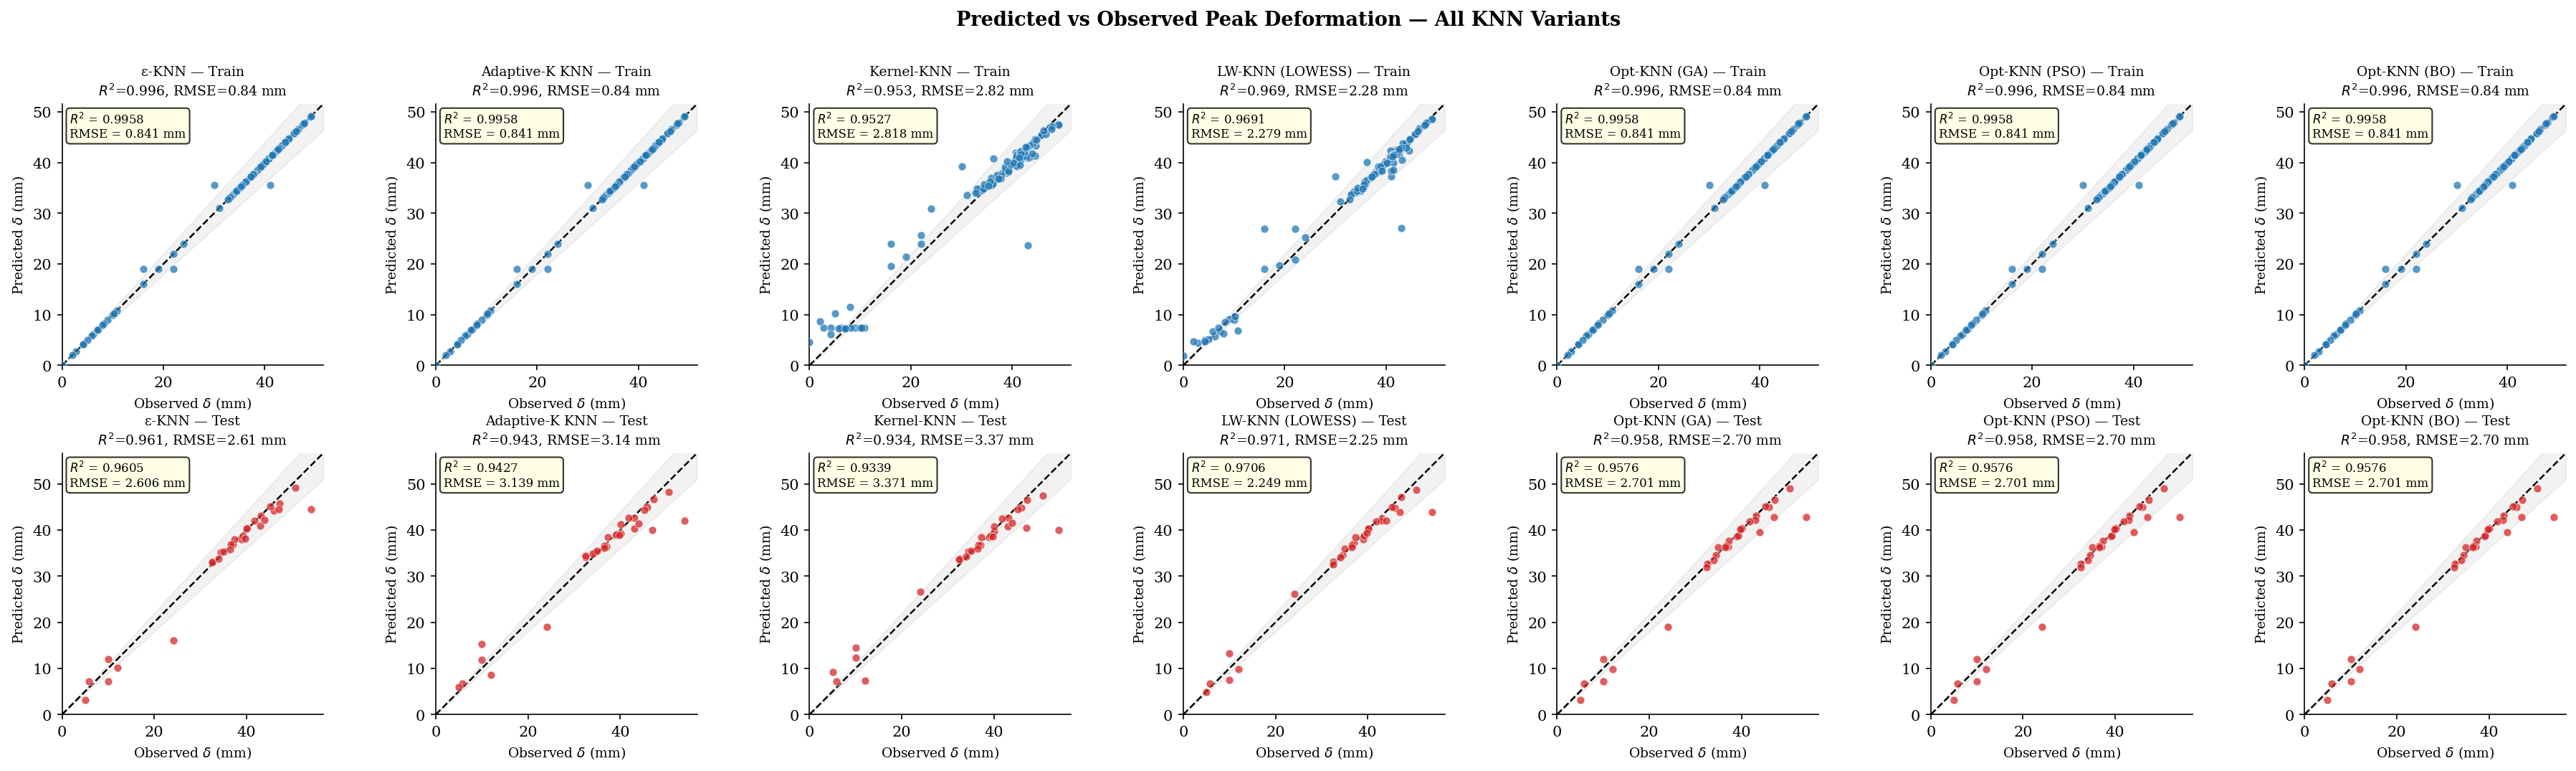

In [53]:
# ════════════════════════════════════════════════════════════════════════════
# 8.1  Predicted vs Observed scatter plots  (Train & Test)
# ════════════════════════════════════════════════════════════════════════════
N_MODELS = len(fitted_models)
fig, axes = plt.subplots(2, N_MODELS, figsize=(3.5 * N_MODELS, 7),
                          sharex=False, sharey=False)

lim_pad = 1.05
for col, (name, preds) in enumerate(predictions.items()):
    for row, (split, y_true, y_pred) in enumerate(
        [('Train', y_train.values, preds['train']),
         ('Test',  y_test.values,  preds['test'])]):

        ax  = axes[row, col]
        lim = [0, max(y_true.max(), y_pred.max()) * lim_pad]
        r2  = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        ax.scatter(y_true, y_pred, s=28, alpha=0.75,
                   color='#1f77b4' if split == 'Train' else '#d62728',
                   edgecolors='white', linewidths=0.4, zorder=3)
        ax.plot(lim, lim, 'k--', lw=1.2, zorder=2, label='Perfect fit')
        # ±10 % bands
        x_ref = np.linspace(*lim, 200)
        ax.fill_between(x_ref, 0.9*x_ref, 1.1*x_ref,
                        alpha=0.10, color='grey', label='±10 %')
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel(r'Observed $\delta$ (mm)', fontsize=9)
        ax.set_ylabel(r'Predicted $\delta$ (mm)', fontsize=9)
        ax.set_title(f'{name} — {split}\n$R^2$={r2:.3f}, RMSE={rmse:.2f} mm',
                     fontsize=9)
        ax.set_aspect('equal', adjustable='box')

        # Annotation box
        ax.text(0.03, 0.97,
                f'$R^2$ = {r2:.4f}\nRMSE = {rmse:.3f} mm',
                transform=ax.transAxes, va='top', ha='left',
                fontsize=8, bbox=dict(boxstyle='round,pad=0.3',
                                      facecolor='lightyellow', alpha=0.8))

plt.suptitle('Predicted vs Observed Peak Deformation — All KNN Variants',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_01_predicted_vs_observed.pdf')
plt.show()

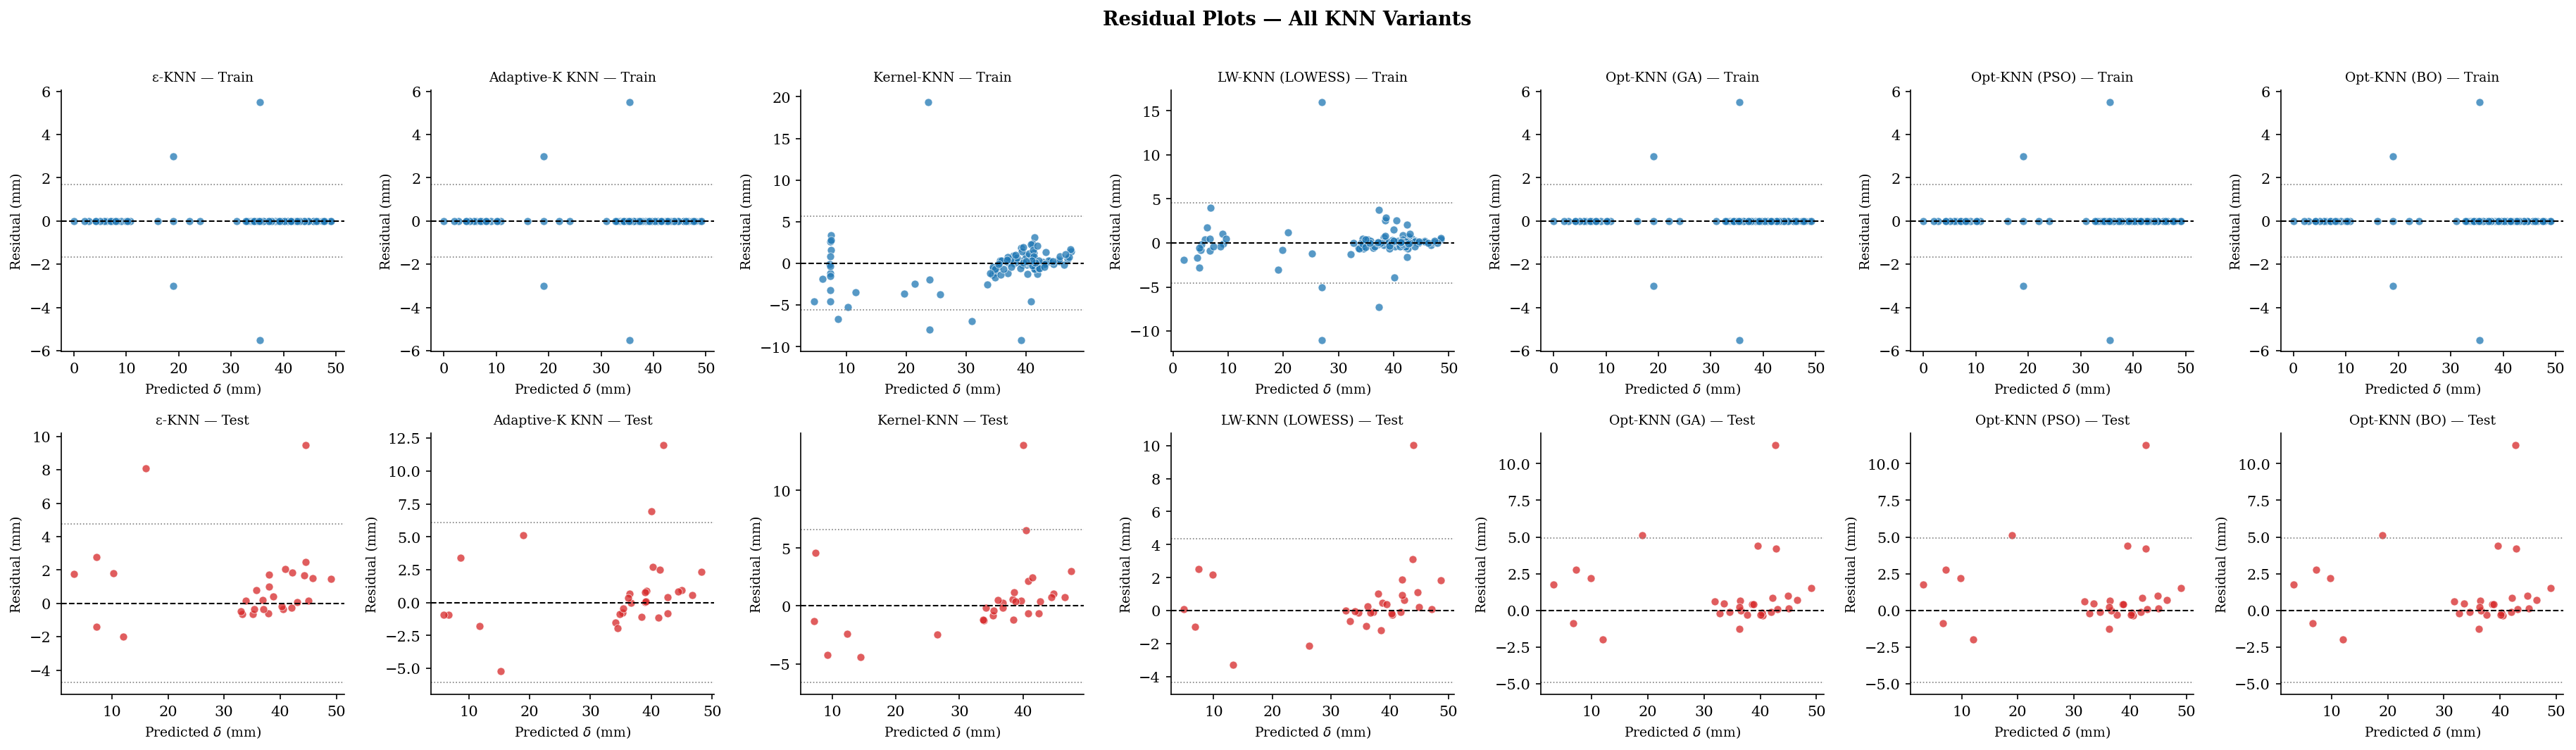

In [54]:
# ════════════════════════════════════════════════════════════════════════════
# 8.2  Residual plots
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, N_MODELS, figsize=(3.5 * N_MODELS, 7))

for col, (name, preds) in enumerate(predictions.items()):
    for row, (split, y_true, y_pred) in enumerate(
        [('Train', y_train.values, preds['train']),
         ('Test',  y_test.values,  preds['test'])]):

        ax = axes[row, col]
        residuals = y_true - y_pred
        color = '#1f77b4' if split == 'Train' else '#d62728'

        ax.scatter(y_pred, residuals, s=28, alpha=0.75,
                   color=color, edgecolors='white', linewidths=0.4)
        ax.axhline(0, color='k', lw=1.0, ls='--')
        ax.axhline( 2*residuals.std(), color='grey', lw=0.8, ls=':')
        ax.axhline(-2*residuals.std(), color='grey', lw=0.8, ls=':')
        ax.set_xlabel(r'Predicted $\delta$ (mm)', fontsize=9)
        ax.set_ylabel('Residual (mm)', fontsize=9)
        ax.set_title(f'{name} — {split}', fontsize=9)

plt.suptitle('Residual Plots — All KNN Variants',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_02_residuals.pdf')
plt.show()

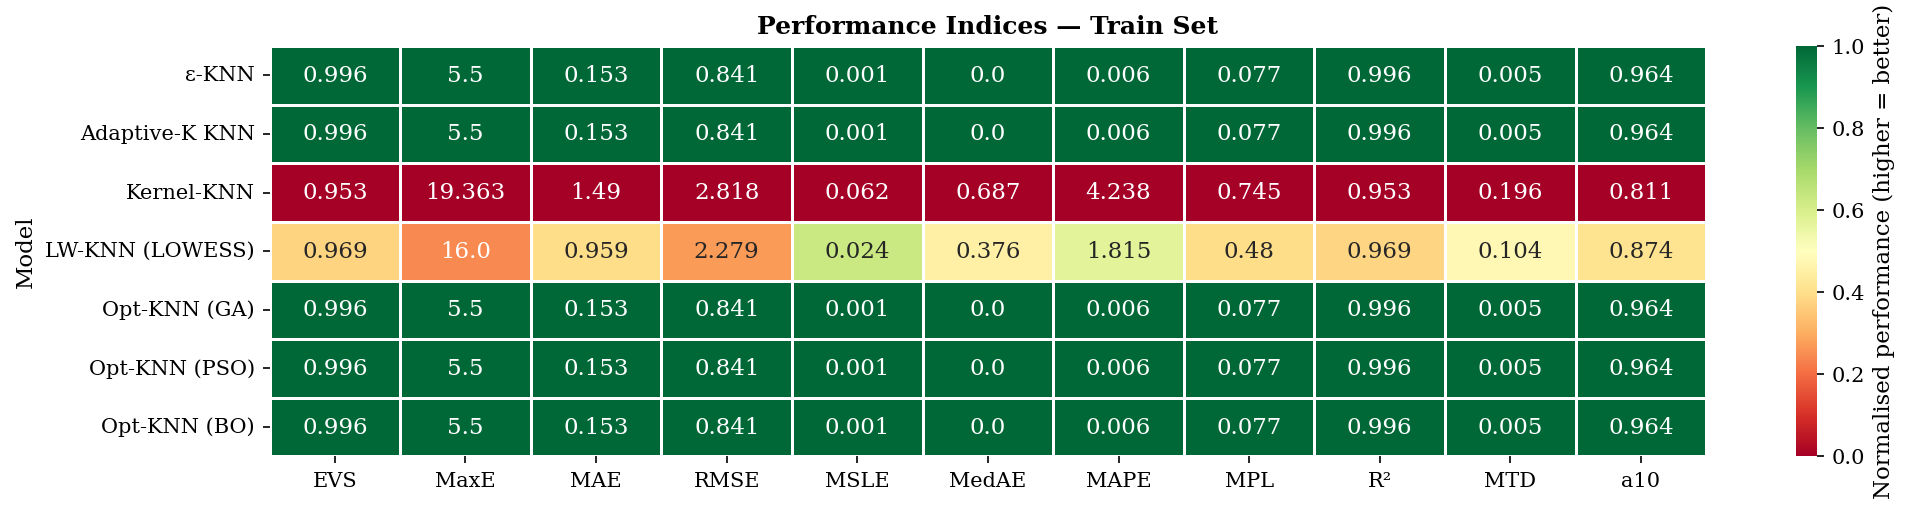

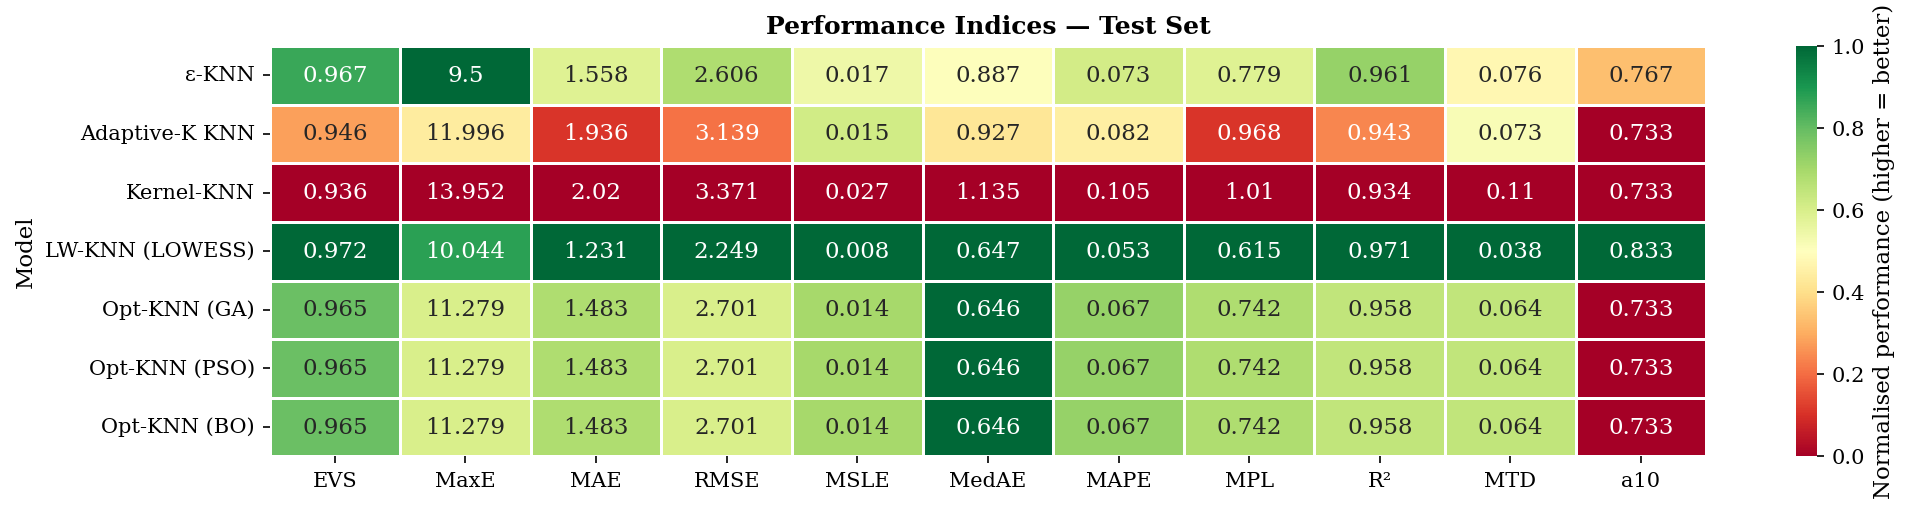

In [55]:
# ════════════════════════════════════════════════════════════════════════════
# 8.3  Performance metrics heatmap
# ════════════════════════════════════════════════════════════════════════════
for split in ('Train', 'Test'):
    sub = results_df.xs(split, level='Split').copy()
    # For error metrics, lower is better → invert for colour mapping
    err_cols  = ['MaxE','MAE','RMSE','MSLE','MedAE','MAPE','MPL','MTD']
    good_cols = ['EVS','R²','a10']

    fig, ax = plt.subplots(figsize=(14, 3.5))
    norm_sub = sub.copy()
    for c in err_cols:  norm_sub[c] = 1 - (sub[c] - sub[c].min()) / (sub[c].max() - sub[c].min() + 1e-10)
    for c in good_cols: norm_sub[c] =     (sub[c] - sub[c].min()) / (sub[c].max() - sub[c].min() + 1e-10)

    sns.heatmap(norm_sub.astype(float), annot=sub.round(3).astype(str),
                fmt='', cmap='RdYlGn', linewidths=0.5, ax=ax,
                cbar_kws={'label': 'Normalised performance (higher = better)'})
    ax.set_title(f'Performance Indices — {split} Set', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    plt.tight_layout()
    plt.savefig(f'fig_03_heatmap_{split.lower()}.pdf')
    plt.show()

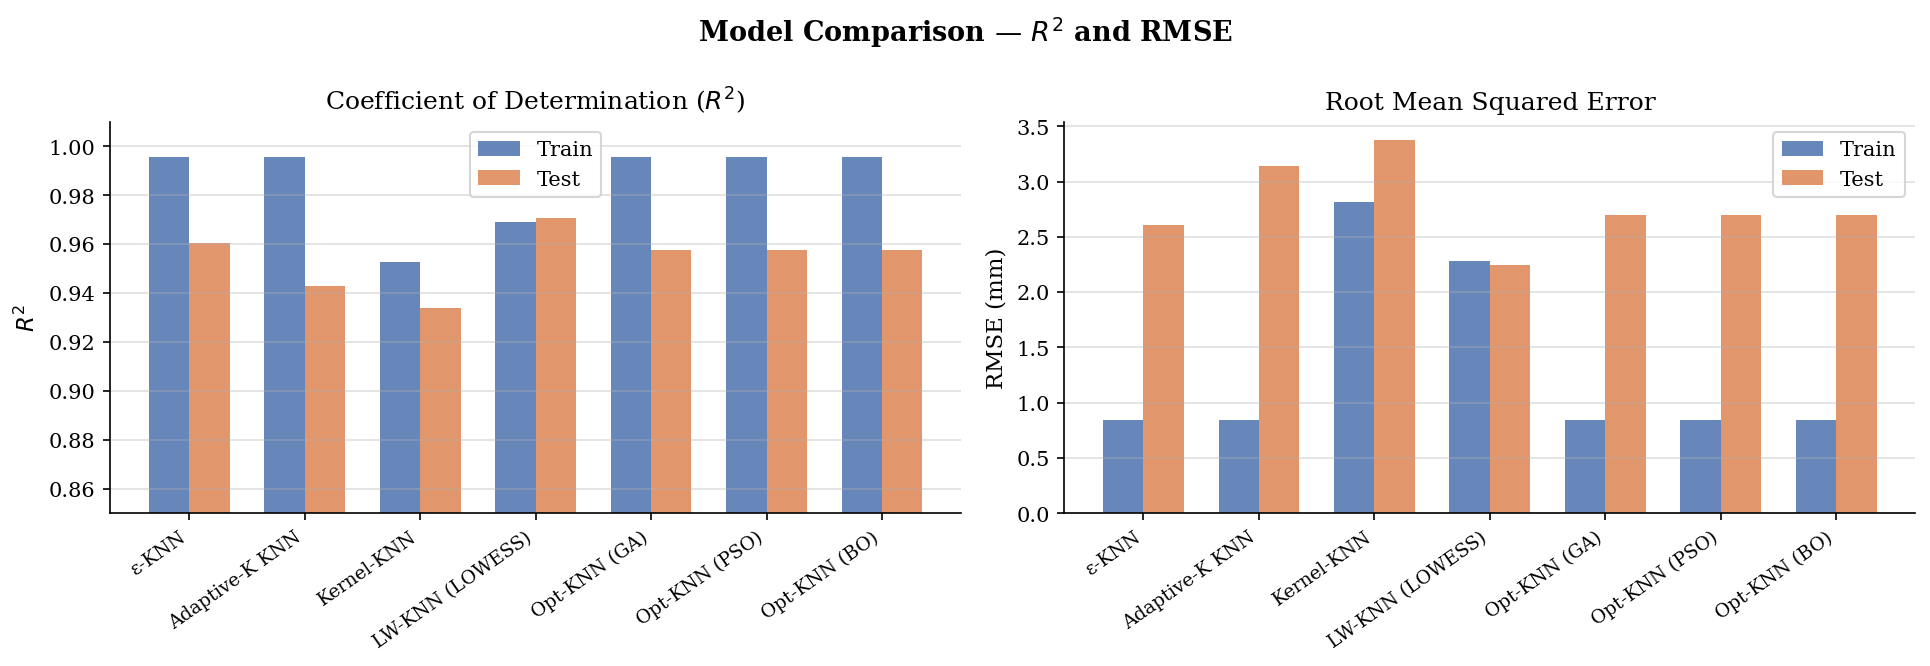

In [56]:
# ════════════════════════════════════════════════════════════════════════════
# 8.4  Grouped bar chart — R² and RMSE comparison
# ════════════════════════════════════════════════════════════════════════════
model_names = list(fitted_models.keys())
r2_train    = [results_df.loc[(m,'Train'),'R²']   for m in model_names]
r2_test     = [results_df.loc[(m,'Test') ,'R²']   for m in model_names]
rmse_train  = [results_df.loc[(m,'Train'),'RMSE'] for m in model_names]
rmse_test   = [results_df.loc[(m,'Test') ,'RMSE'] for m in model_names]

x  = np.arange(len(model_names))
bw = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

b1 = ax1.bar(x - bw/2, r2_train, bw, label='Train', color='#4C72B0', alpha=0.85)
b2 = ax1.bar(x + bw/2, r2_test,  bw, label='Test',  color='#DD8452', alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(model_names, rotation=35, ha='right', fontsize=9)
ax1.set_ylabel(r'$R^2$'); ax1.set_ylim([0.85, 1.01])
ax1.set_title(r'Coefficient of Determination ($R^2$)')
ax1.legend(); ax1.yaxis.grid(True, alpha=0.4)

b3 = ax2.bar(x - bw/2, rmse_train, bw, label='Train', color='#4C72B0', alpha=0.85)
b4 = ax2.bar(x + bw/2, rmse_test,  bw, label='Test',  color='#DD8452', alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(model_names, rotation=35, ha='right', fontsize=9)
ax2.set_ylabel('RMSE (mm)'); ax2.set_title('Root Mean Squared Error')
ax2.legend(); ax2.yaxis.grid(True, alpha=0.4)

plt.suptitle('Model Comparison — $R^2$ and RMSE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_04_bar_r2_rmse.pdf')
plt.show()

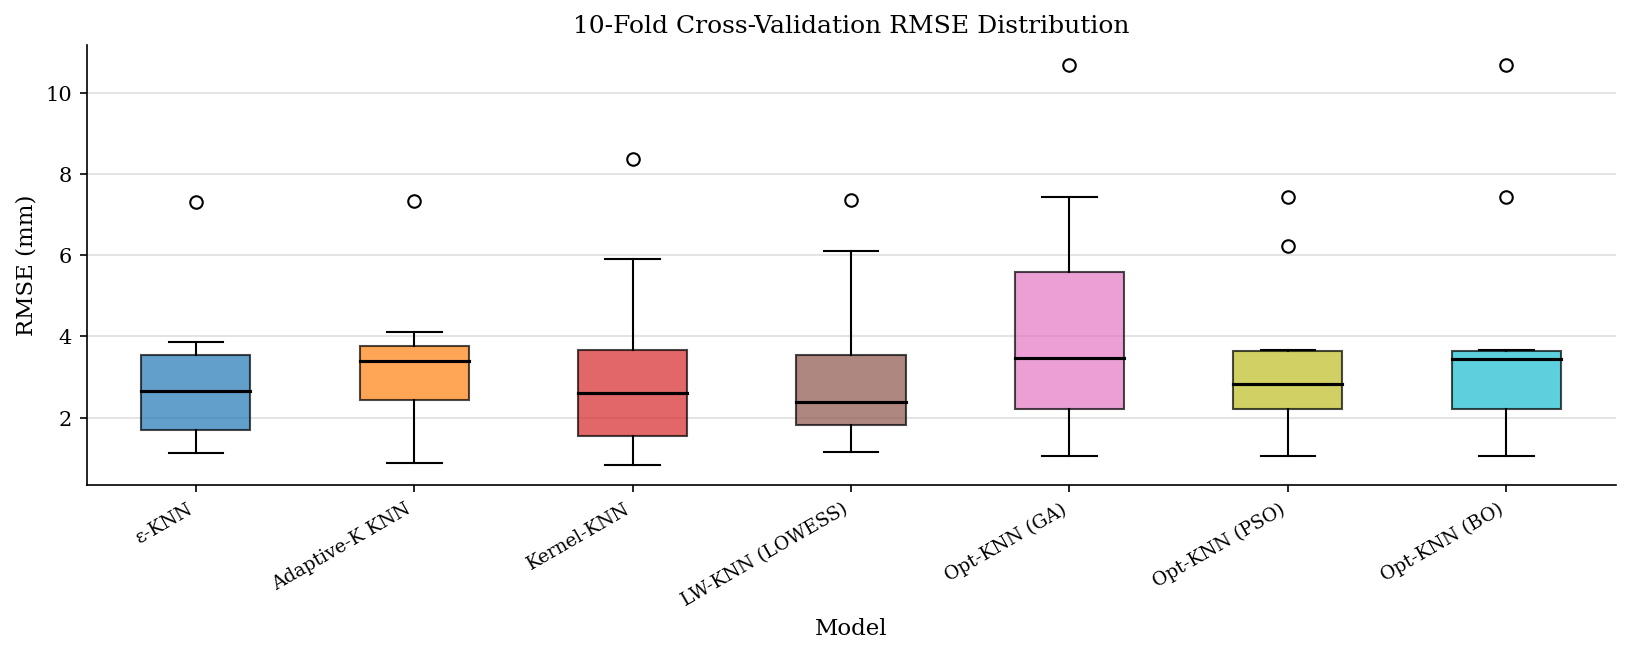

In [57]:
# ════════════════════════════════════════════════════════════════════════════
# 8.5  Cross-validation box plot
# ════════════════════════════════════════════════════════════════════════════
cv_scores_all = {}
for name, model in fitted_models.items():
    scores = -cross_val_score(model, X_train_s, y_train.values,
                               cv=kf, scoring='neg_root_mean_squared_error')
    cv_scores_all[name] = scores

fig, ax = plt.subplots(figsize=(11, 4.5))
bp = ax.boxplot([cv_scores_all[m] for m in model_names],
                labels=model_names, patch_artist=True,
                medianprops=dict(color='black', lw=1.5))
palette = plt.cm.tab10(np.linspace(0, 1, len(model_names)))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color); patch.set_alpha(0.7)

ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('RMSE (mm)', fontsize=11)
ax.set_title(f'{CV_FOLDS}-Fold Cross-Validation RMSE Distribution', fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=9)
ax.yaxis.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('fig_05_cv_boxplot.pdf')
plt.show()

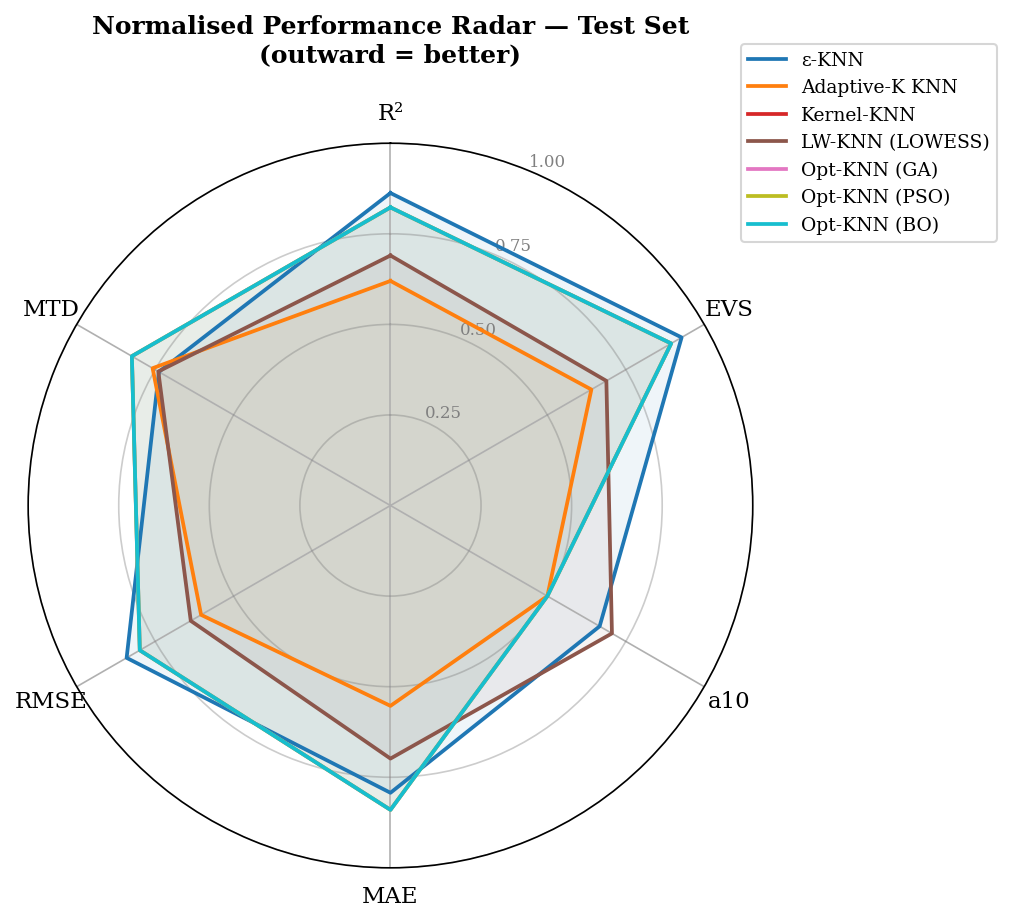

In [58]:
# ════════════════════════════════════════════════════════════════════════════
# 8.6  Spider (Radar) plot — normalised performance indices (Test set)
# ════════════════════════════════════════════════════════════════════════════
SPIDER_METRICS = ['R²', 'EVS', 'a10', 'MAE', 'RMSE', 'MTD']
# Invert error metrics so that all axes point in the "better" direction
INVERT = {'MAE', 'RMSE', 'MTD'}

train_raw = results_df.xs('Train', level='Split')[SPIDER_METRICS].copy()
test_raw  = results_df.xs('Test',  level='Split')[SPIDER_METRICS].copy()

normed = pd.DataFrame(index=test_raw.index)
for col in SPIDER_METRICS:
    # Normalise train and test INDEPENDENTLY using their own min/max
    tr = train_raw[col].copy()
    te = test_raw[col].copy()

    tr_min, tr_max = tr.min(), tr.max()
    te_min, te_max = te.min(), te.max()

    tr_norm = (tr - tr_min) / (tr_max - tr_min + 1e-12)
    te_norm = (te - te_min) / (te_max - te_min + 1e-12)

    if col in INVERT:
        tr_norm = 1 - tr_norm
        te_norm = 1 - te_norm

    normed[col] = (tr_norm + te_norm) / 2

labels_spider = SPIDER_METRICS
N_sp = len(labels_spider)
angles = [n / float(N_sp) * 2 * pi for n in range(N_sp)]
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(pi / 2); ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_spider, size=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(['0.25','0.50','0.75','1.00'], size=8, color='grey')
ax.yaxis.grid(True, color='grey', alpha=0.4)

colors = plt.cm.tab10(np.linspace(0, 1, len(model_names)))
for (mname, row), color in zip(normed.iterrows(), colors):
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, lw=1.8, color=color, label=mname)
    ax.fill(angles, vals, alpha=0.07, color=color)

ax.set_title('Normalised Performance Radar — Test Set\n(outward = better)',
             size=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig('fig_06_spider.pdf')
plt.show()

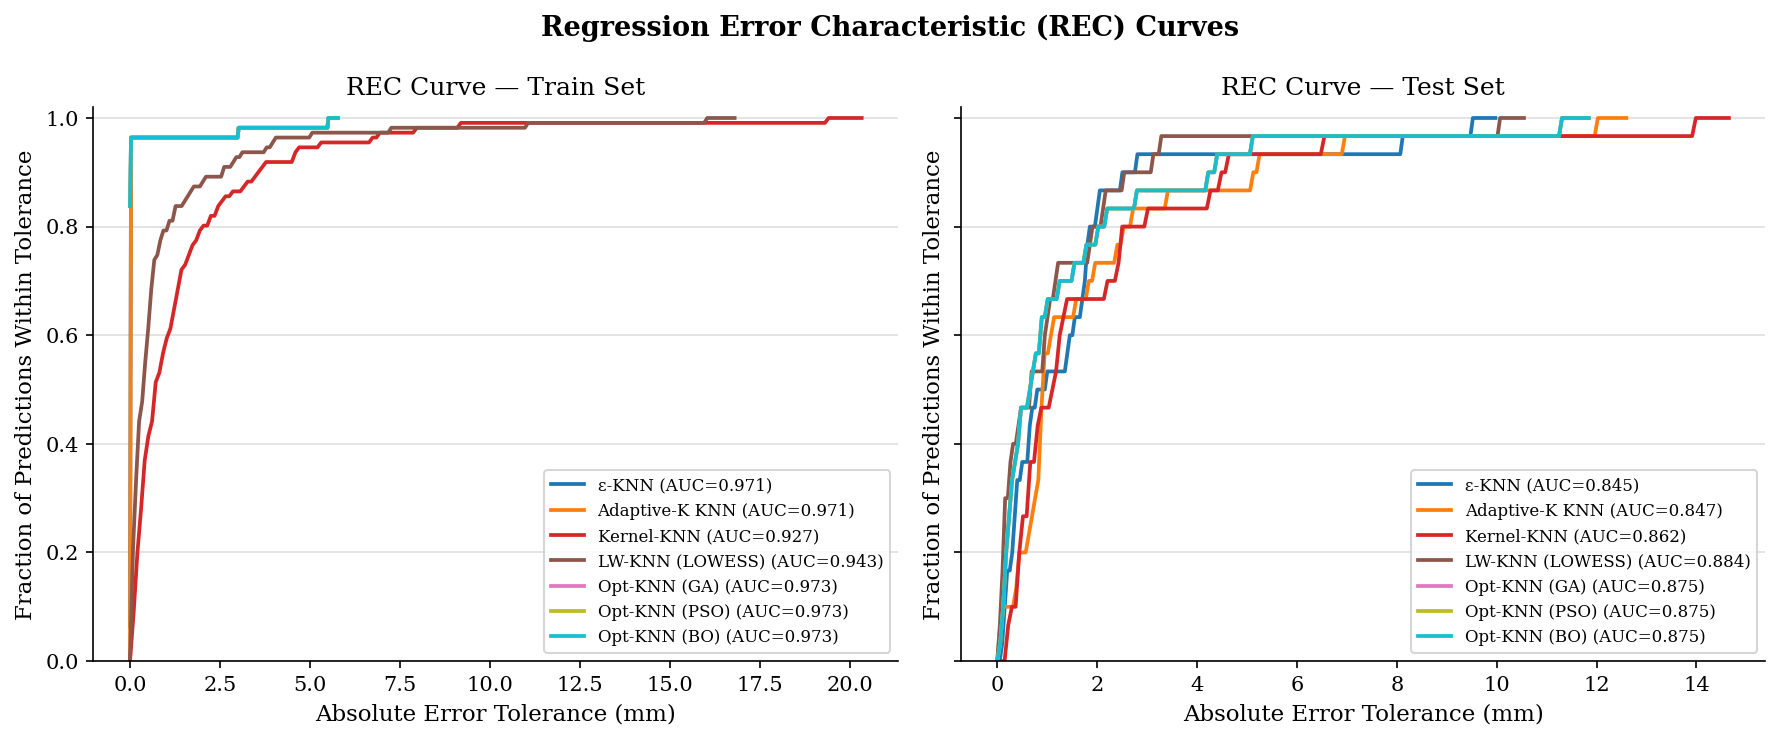

In [59]:
# ════════════════════════════════════════════════════════════════════════════
# 8.7  Regression Error Characteristic (REC) curve
# ════════════════════════════════════════════════════════════════════════════
def rec_curve(y_true, y_pred, n_tol: int = 200):
    """Return (tolerance_grid, fraction_within_tolerance) for an REC curve."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    abs_err   = np.abs(y_true - y_pred)
    max_err   = abs_err.max()
    tol_grid  = np.linspace(0, max_err * 1.05, n_tol)
    fractions = [(abs_err <= t).mean() for t in tol_grid]
    return tol_grid, fractions


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
colors    = plt.cm.tab10(np.linspace(0, 1, len(model_names)))

for ax, (split, y_true) in zip(axes, [('Train', y_train.values), ('Test', y_test.values)]):
    for (name, preds), color in zip(predictions.items(), colors):
        y_pred = preds['train'] if split == 'Train' else preds['test']
        tol, frac = rec_curve(y_true, y_pred)
        auc = np.trapz(frac, tol) / tol.max()   # normalised AUC
        ax.plot(tol, frac, lw=1.8, color=color,
                label=f'{name} (AUC={auc:.3f})')

    ax.set_xlabel('Absolute Error Tolerance (mm)', fontsize=11)
    ax.set_ylabel('Fraction of Predictions Within Tolerance', fontsize=11)
    ax.set_title(f'REC Curve — {split} Set', fontsize=12)
    ax.legend(fontsize=8, loc='lower right')
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_ylim([0, 1.02])

plt.suptitle('Regression Error Characteristic (REC) Curves',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_07_rec_curve.pdf')
plt.show()

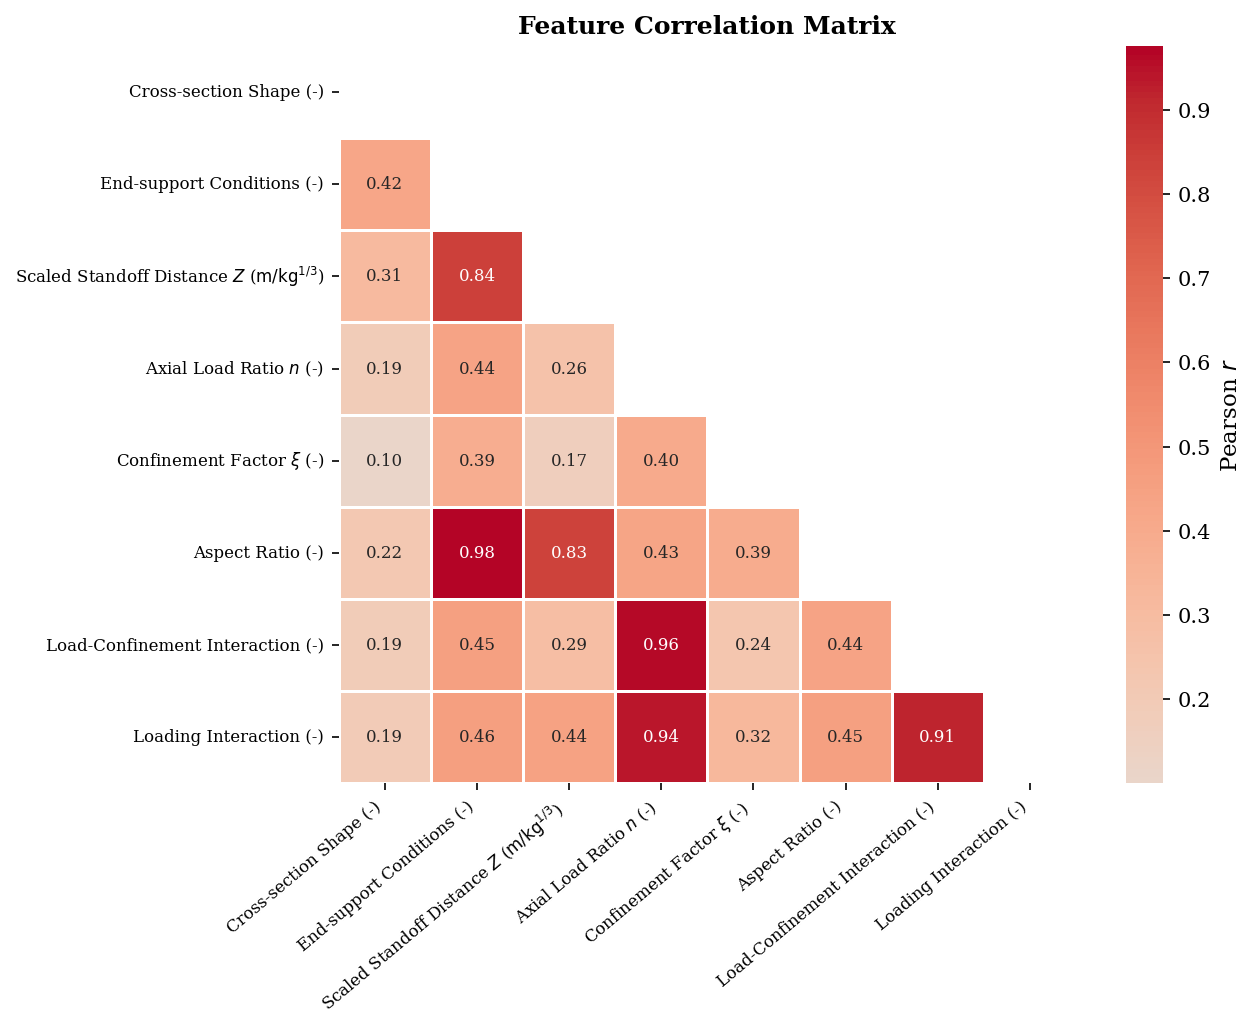

In [60]:
# ════════════════════════════════════════════════════════════════════════════
# 8.8  Feature correlation matrix
# ════════════════════════════════════════════════════════════════════════════
X_corr = pd.DataFrame(X_train_s, columns=FEATURE_NAMES)
X_corr.columns = [FEATURE_LABELS.get(c, c) for c in X_corr.columns]

corr_matrix = X_corr.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Pearson $r$'},
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('fig_08_correlation.pdf')
plt.show()

## 9. SHAP Interpretability Analysis <a id='9-shap'></a>

SHAP (SHapley Additive exPlanations) is applied to the best-performing model on the **original** (unscaled) feature space using a KernelExplainer for model-agnostic attribution.  
All axes use formal feature labels.

In [61]:
# ════════════════════════════════════════════════════════════════════════════
# 9.1  Select best model (highest test R²) and build SHAP explainer
# ════════════════════════════════════════════════════════════════════════════
best_model_name = max(
    predictions,
    key=lambda m: r2_score(y_test.values, predictions[m]['test'])
)
best_model = fitted_models[best_model_name]
print(f"  Best model (Test R²): {best_model_name}")

# SHAP uses the ORIGINAL (untransformed) feature names
X_train_df = pd.DataFrame(X_train_s, columns=FEATURE_NAMES)
X_test_df  = pd.DataFrame(X_test_s,  columns=FEATURE_NAMES)

# Use a summarised background for efficiency
background = shap.sample(X_train_df, 50, random_state=RANDOM_STATE)

explainer   = shap.KernelExplainer(best_model.predict, background)
shap_values = explainer.shap_values(X_test_df, nsamples=100)

  Best model (Test R²): LW-KNN (LOWESS)


  0%|          | 0/30 [00:00<?, ?it/s]

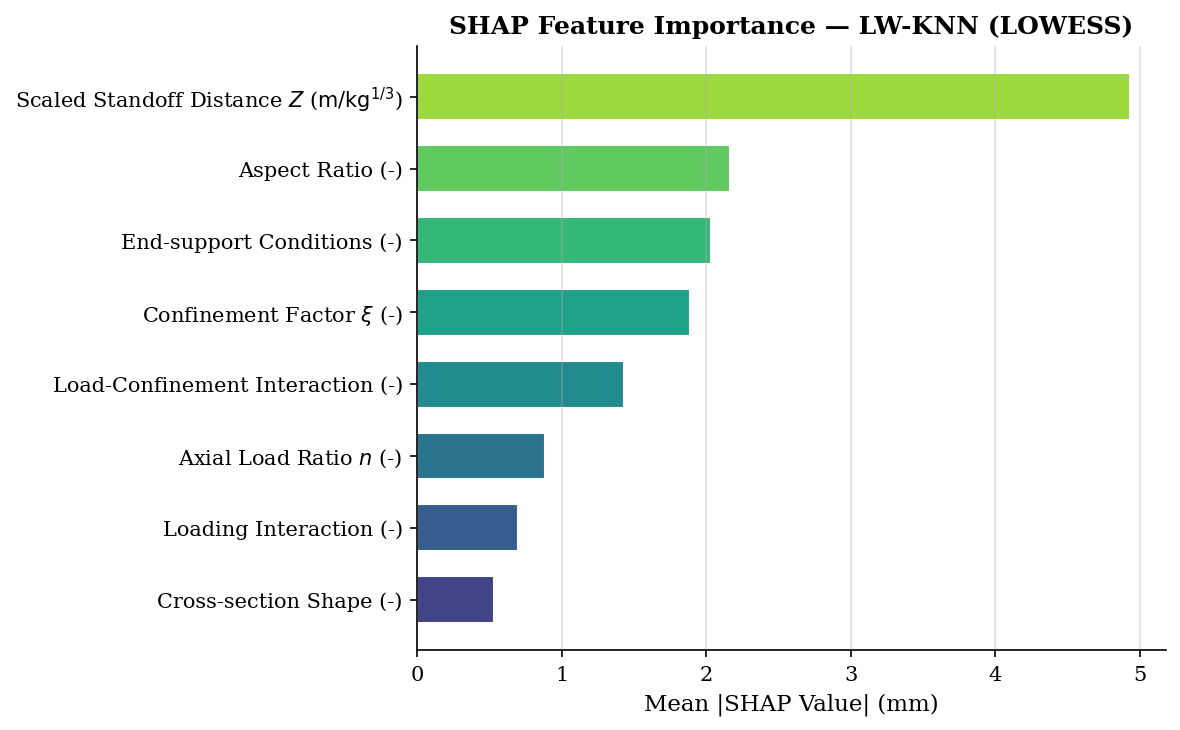

In [62]:
# ════════════════════════════════════════════════════════════════════════════
# 9.2  SHAP feature importance (bar)
# ════════════════════════════════════════════════════════════════════════════
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature'        : [FEATURE_LABELS.get(f, f) for f in FEATURE_NAMES],
    'Mean |SHAP|'    : mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(importance_df['Feature'], importance_df['Mean |SHAP|'],
               color=plt.cm.viridis(np.linspace(0.2, 0.85, len(FEATURE_NAMES))),
               edgecolor='white', height=0.65)
ax.set_xlabel('Mean |SHAP Value| (mm)', fontsize=11)
ax.set_title(f'SHAP Feature Importance — {best_model_name}', fontsize=12, fontweight='bold')
ax.xaxis.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('fig_09_shap_importance.pdf')
plt.show()

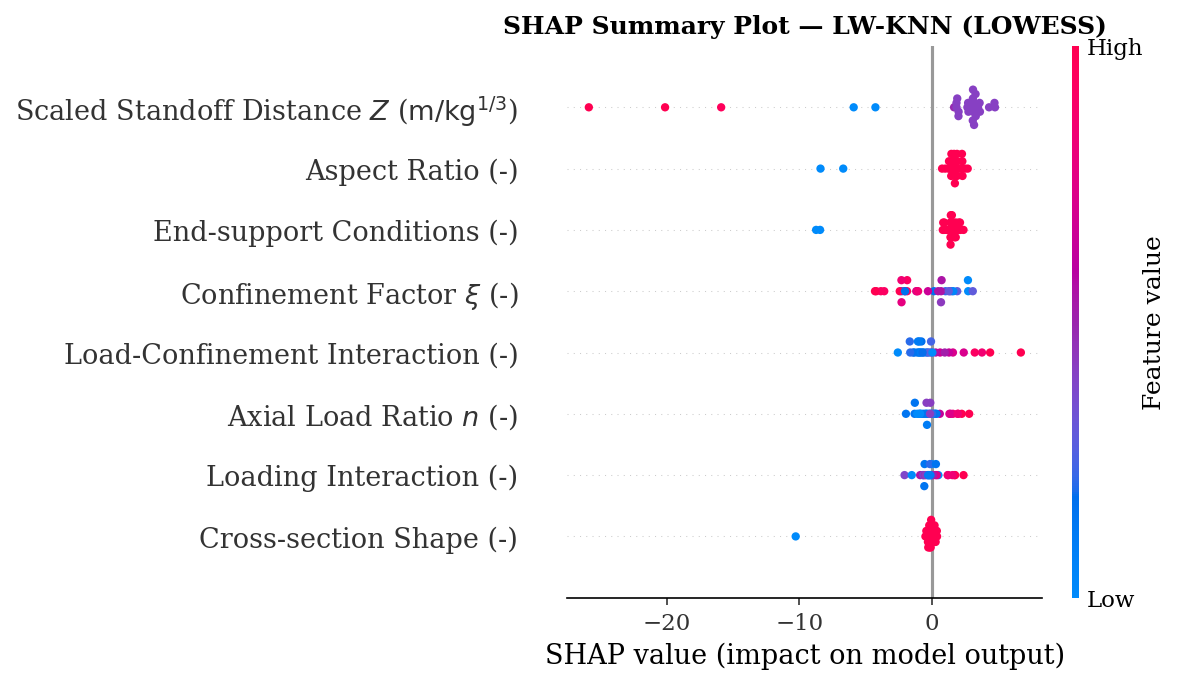

In [63]:
# ════════════════════════════════════════════════════════════════════════════
# 9.3  SHAP beeswarm / summary plot
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))
shap.summary_plot(
    shap_values, X_test_df,
    feature_names=[FEATURE_LABELS.get(f, f) for f in FEATURE_NAMES],
    show=False, plot_type='dot'
)
plt.title(f'SHAP Summary Plot — {best_model_name}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_10_shap_summary.pdf')
plt.show()

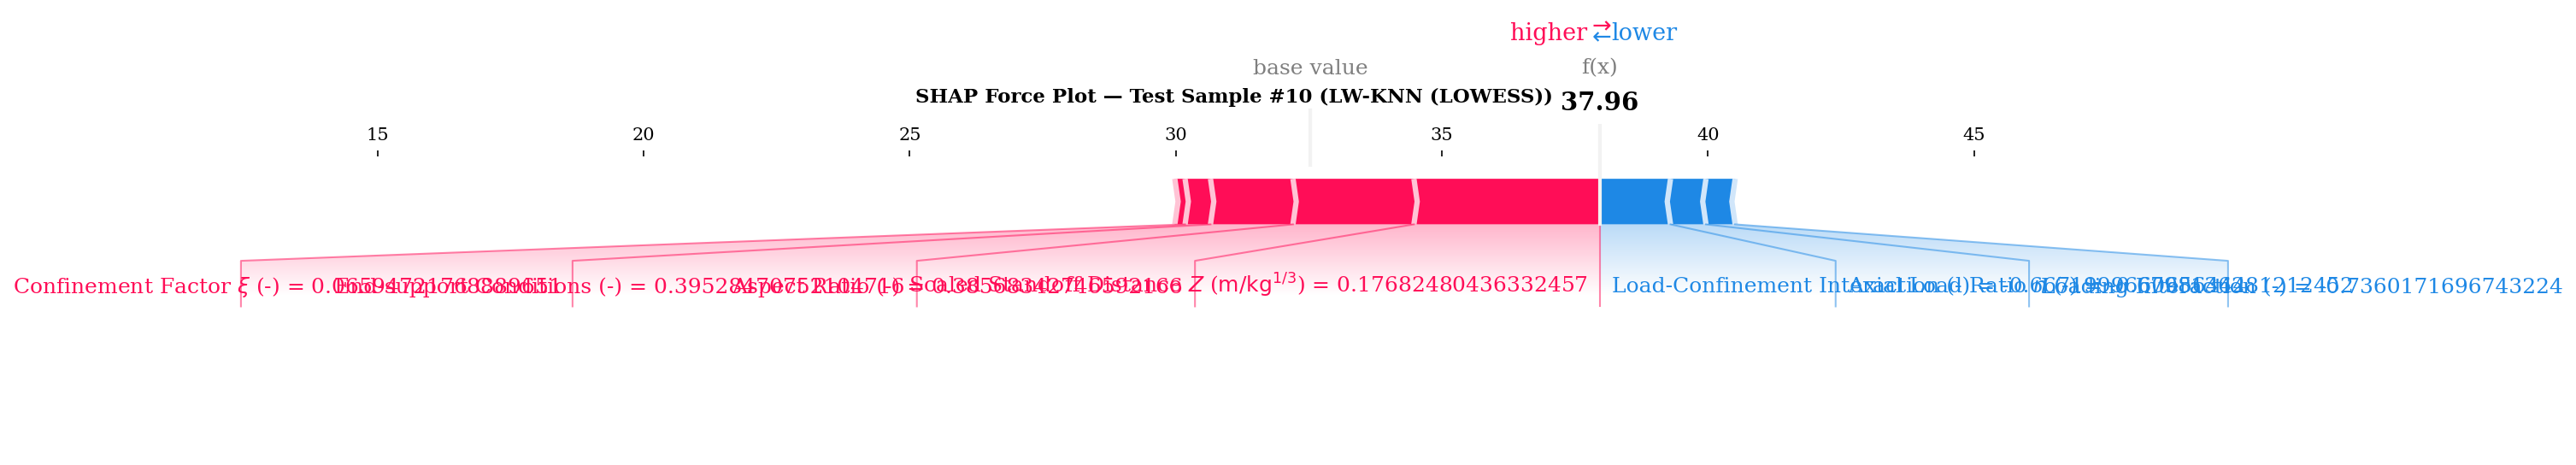

In [64]:
# ════════════════════════════════════════════════════════════════════════════
# 9.4  SHAP force plot — single representative test observation
# ════════════════════════════════════════════════════════════════════════════
# Select the test sample closest to median prediction
test_preds  = predictions[best_model_name]['test']
median_idx  = np.argmin(np.abs(test_preds - np.median(test_preds)))

shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[median_idx],
    X_test_df.iloc[median_idx],
    feature_names=[FEATURE_LABELS.get(f, f) for f in FEATURE_NAMES],
    matplotlib=True, show=False
)
plt.title(f'SHAP Force Plot — Test Sample #{median_idx} ({best_model_name})',
          fontsize=11, fontweight='bold', pad=30)
plt.savefig('fig_11_shap_force.pdf', bbox_inches='tight')
plt.show()

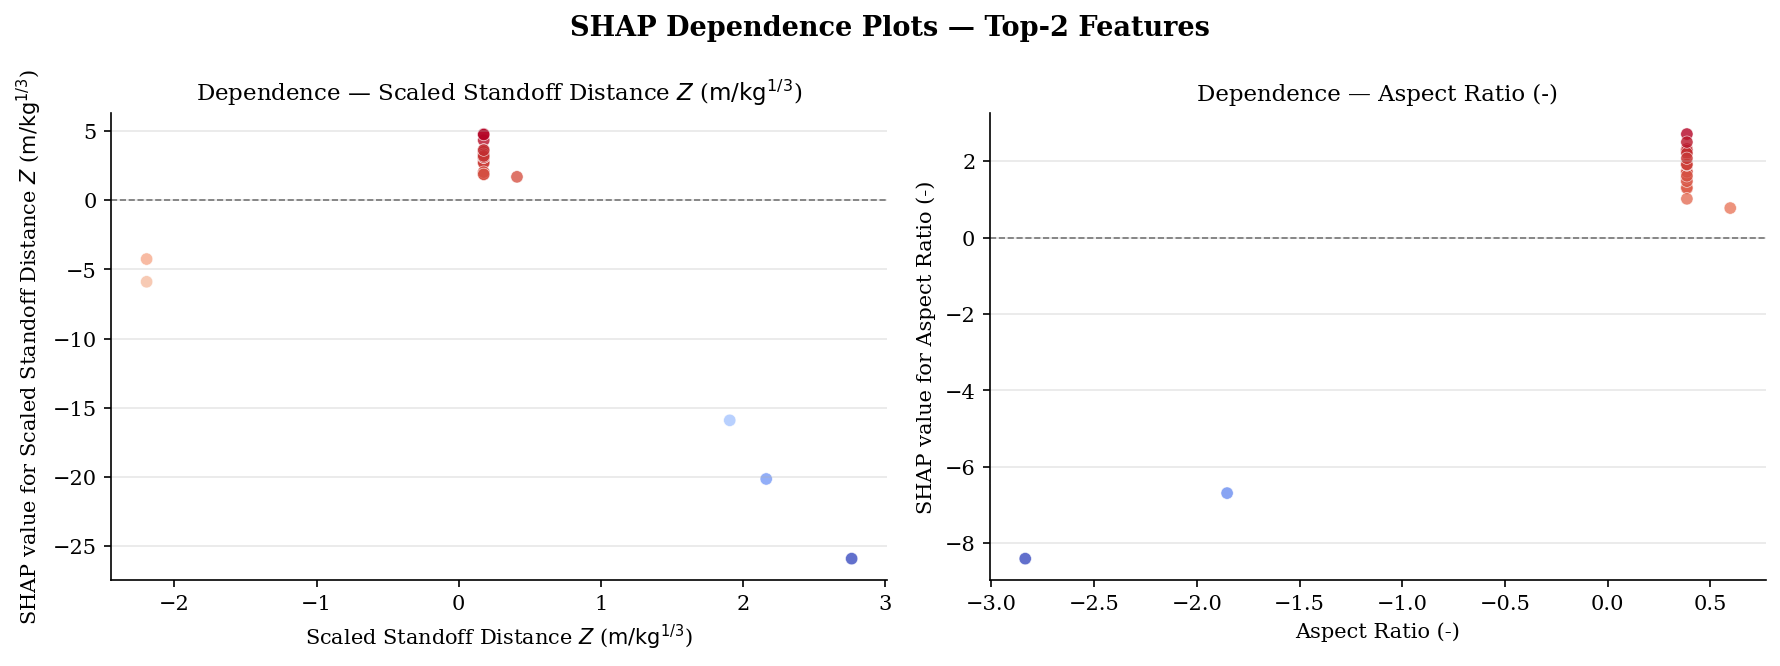

In [65]:
# ════════════════════════════════════════════════════════════════════════════
# 9.5  SHAP dependence plots — top-2 most important features
# ════════════════════════════════════════════════════════════════════════════
top2_idx = np.argsort(mean_abs_shap)[::-1][:2]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, idx in zip(axes, top2_idx):
    fname      = FEATURE_NAMES[idx]
    fname_label = FEATURE_LABELS.get(fname, fname)
    ax.scatter(X_test_df.iloc[:, idx], shap_values[:, idx],
               c=shap_values[:, idx], cmap='coolwarm', alpha=0.8, s=35,
               edgecolors='white', linewidths=0.3)
    ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlabel(fname_label, fontsize=10)
    ax.set_ylabel(f'SHAP value for {fname_label}', fontsize=10)
    ax.set_title(f'Dependence — {fname_label}', fontsize=11)
    ax.yaxis.grid(True, alpha=0.3)

plt.suptitle('SHAP Dependence Plots — Top-2 Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_12_shap_dependence.pdf')
plt.show()

In [66]:
import pickle

# Save best model — LW-KNN (LOWESS)
with open('knn.pkl', 'wb') as f:
    pickle.dump(fitted_models['LW-KNN (LOWESS)'], f)

print("Model saved → knn.pkl")

Model saved → knn.pkl
